In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df=pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
df.shape

(768, 9)

In [3]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [4]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [8]:
df["Outcome"].value_counts(normalize=True)*100

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

## Initial Data Understanding

In this step, I explored the dataset structure, checked the column names, data types, missing values, summary statistics, and the distribution of the target column `Outcome`.

The target column is `Outcome`:
- 0 means the patient does not have diabetes
- 1 means the patient has diabetes

In [9]:
# Show the percentage of each class
outcome_percentage = df["Outcome"].value_counts(normalize=True) * 100

outcome_percentage

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

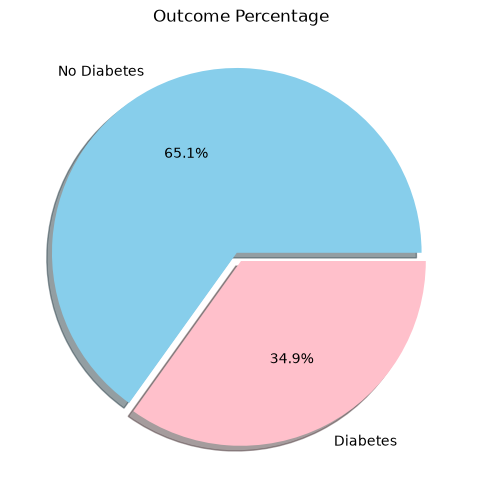

In [10]:
plt.figure(figsize=(6,6))
plt.pie(outcome_percentage.values,colors=["skyblue","pink"],shadow=True,
        explode=[0.05,0],labels=outcome_percentage.index.map({0: "No Diabetes", 1: "Diabetes"}),
        autopct="%1.1f%%")
plt.title("Outcome Percentage")
plt.show()

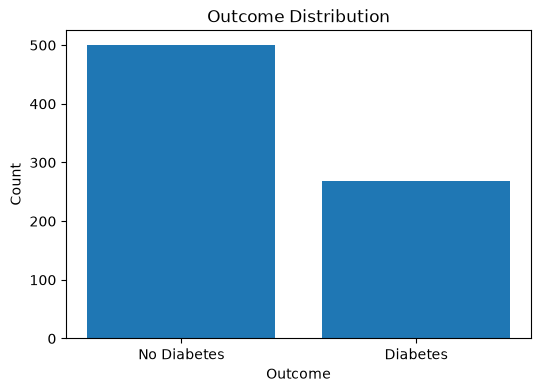

In [11]:
# Plot the target distribution
plt.figure(figsize=(6, 4))
plt.bar(df["Outcome"].value_counts().index,df["Outcome"].value_counts().values)
plt.title("Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.xticks([0, 1], ["No Diabetes", "Diabetes"], rotation=0)

plt.show()

## Target Distribution

The dataset is not perfectly balanced.

About 65% of patients do not have diabetes, while about 35% have diabetes.

This means there is a mild class imbalance.

Because this is a medical classification problem, accuracy alone is not enough. Recall for class 1 is important because we want to detect as many diabetic patients as possible.

In [12]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [13]:
# Compare average Glucose between diabetes and no diabetes
df.groupby("Outcome")["Glucose"].mean()

Outcome
0    109.980000
1    141.257463
Name: Glucose, dtype: float64

<Figure size 600x400 with 0 Axes>

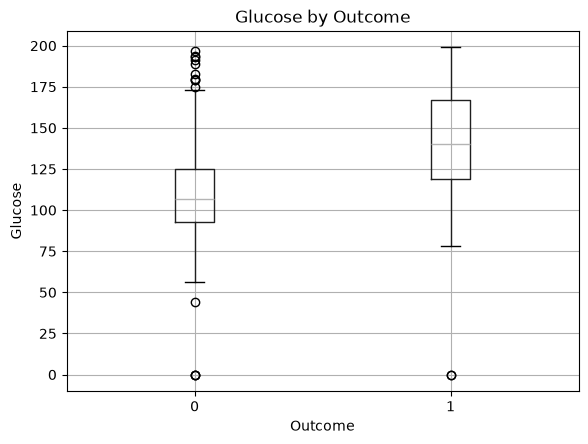

In [14]:
# Plot Glucose distribution by Outcome
plt.figure(figsize=(6, 4))

df.boxplot(column="Glucose", by="Outcome")

plt.title("Glucose by Outcome")
plt.suptitle("")
plt.xlabel("Outcome")
plt.ylabel("Glucose")

plt.show()

In [15]:
df.groupby("Outcome")["BMI"].mean()

Outcome
0    30.304200
1    35.142537
Name: BMI, dtype: float64

<Figure size 600x400 with 0 Axes>

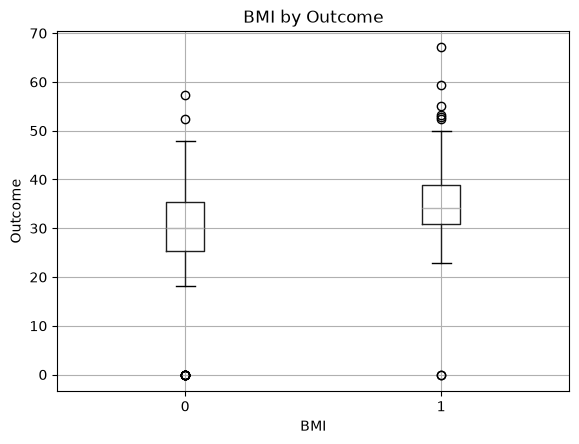

In [16]:
plt.figure(figsize=(6,4))
df.boxplot(column="BMI", by="Outcome")
plt.title("BMI by Outcome")
plt.suptitle("")
plt.xlabel("BMI")
plt.ylabel("Outcome")
plt.show()


In [17]:
df.groupby("Outcome")["Age"].mean()

Outcome
0    31.190000
1    37.067164
Name: Age, dtype: float64

<Figure size 600x400 with 0 Axes>

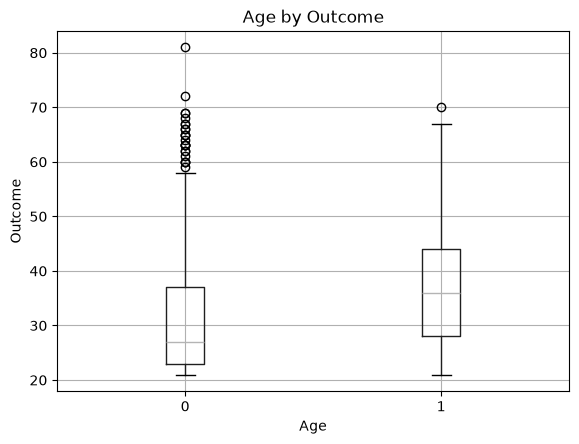

In [18]:
plt.figure(figsize=(6,4))
df.boxplot(column="Age",by="Outcome")
plt.suptitle("")
plt.xlabel("Age")
plt.ylabel("Outcome")
plt.title("Age by Outcome")
plt.show()

## Medical Feature Analysis

I compared Glucose, BMI, and Age between patients with diabetes and patients without diabetes.

I also checked zero values in medical columns because some zero values are not medically realistic, such as Glucose = 0, BloodPressure = 0, and BMI = 0.

These zero values may represent missing data and should be handled before training the model.

In [19]:
# Columns where zero values may be medically unrealistic
zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

zero_counts=(df[zero_cols]==0).sum()
zero_counts

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

In [20]:
# Replace zero values with NaN
df[zero_cols] = df[zero_cols].replace(0, np.nan)

In [21]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [22]:
(df[zero_cols] == 0).sum()

Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

## Handling Unrealistic Zero Values

Some medical columns had zero values that are not realistic, such as Glucose, BloodPressure, Insulin, SkinThickness, and BMI.

I replaced these zero values with NaN so they can be treated as missing values in the preprocessing step.

I did not replace zero values in Pregnancies because having zero pregnancies is medically possible.

In [23]:
# Convert object columns back to numeric
numeric_cols_to_fix = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

df[numeric_cols_to_fix] = df[numeric_cols_to_fix].apply(pd.to_numeric, errors="coerce")

In [24]:
df[zero_cols]=df[zero_cols].fillna(df[zero_cols].median())
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


## Note About Missing Values

Some columns had many unrealistic zero values.

Insulin and SkinThickness had the highest number of missing values after replacing zeros with NaN.

For this project, I filled missing values using the median because it is simple and robust to outliers.

However, columns with a high percentage of missing values may need more careful handling in a real medical machine learning project.

In [25]:
# Check missing values after filling with median
df[zero_cols].isna().sum()

Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

## Filling Missing Values

After replacing unrealistic zero values with NaN, I filled the missing values using the median of each column.

I used the median because it is more robust to outliers than the mean.

In [26]:
# Show all correlations with Outcome
corr = df.corr(numeric_only=True)["Outcome"].sort_values(ascending=False)

print(corr)

Outcome                     1.000000
Glucose                     0.492782
BMI                         0.312038
Age                         0.238356
Pregnancies                 0.221898
SkinThickness               0.214873
Insulin                     0.203790
DiabetesPedigreeFunction    0.173844
BloodPressure               0.165723
Name: Outcome, dtype: float64


In [27]:
X=df.drop(columns="Outcome")
y=df["Outcome"]
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33


In [28]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((614, 8), (154, 8), (614,), (154,))

## Logistic Regression Model

I started with Logistic Regression as a baseline model.

Logistic Regression is commonly used for binary classification problems.

In this project, it predicts whether a patient has diabetes or not.

In [29]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

from sklearn.linear_model import LogisticRegression
log_model=LogisticRegression()
log_model.fit(X_train_scaled,y_train)
y_pred=log_model.predict(X_test_scaled)




In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
accuracy=accuracy_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)

print("accuracy : ", accuracy)
print("precision : ", precision)
print("recall : ", recall)
print("f1 : ", f1)

accuracy :  0.7077922077922078
precision :  0.6
recall :  0.5
f1 :  0.5454545454545454


In [31]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



In [32]:
print(confusion_matrix(y_test,y_pred))

[[82 18]
 [27 27]]


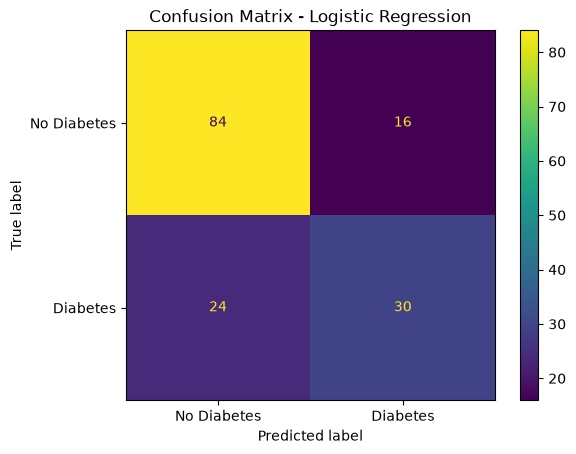

In [46]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm=confusion_matrix(y_test,y_pred)
disp=ConfusionMatrixDisplay(
   confusion_matrix= cm,
   display_labels=["No Diabetes", "Diabetes"]
)
disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

## Logistic Regression Evaluation

The Logistic Regression model achieved an accuracy of about 70.8%.

However, accuracy alone is not enough for this medical classification problem.

The recall for class 1 diabetes is 0.50, which means the model detected only 50% of diabetic patients.

The confusion matrix shows that the model correctly detected 27 diabetic patients, but missed 27 diabetic patients.

False negatives are important in this project because missing a diabetic patient can be risky.

Therefore, this model is a good baseline, but it needs improvement.

## Training Multiple Models

I trained multiple classification models to compare their performance.

The models are:
- Logistic Regression
- KNN
- Decision Tree
- Random Forest
- SVM

Comparing multiple models helps us choose the best model for the problem.

In [33]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC()
}
results=[]
for model_name,model in models.items():
    
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
    "Model": model_name,
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1
    })
results_df=pd.DataFrame(results)
results_df.sort_values(by=["Recall","Accuracy"],ascending=False)
    

,Model,Accuracy,Precision,Recall,F1-score
3,Random Forest,0.779221,0.717391,0.611111,0.660000
1,KNN,0.753247,0.660000,0.611111,0.634615
4,SVM,0.740260,0.652174,0.555556,0.600000
0,Logistic Regression,0.707792,0.600000,0.500000,0.545455
2,Decision Tree,0.681818,0.553191,0.481481,0.514851


## ROC-AUC Evaluation

In this step, I calculate the ROC-AUC score for each model.

ROC-AUC shows how well the model can separate between the two classes:

- Class 0: No Diabetes
- Class 1: Diabetes

Unlike accuracy, ROC-AUC uses predicted probabilities, not only final class predictions.  
This helps me understand how confident the model is when predicting Diabetes.

In [47]:
from sklearn.metrics import roc_auc_score
roc_results = []
for model_name, model in models.items():
    model.fit(X_train_scaled, y_train)
    
    # Check if the model has predict_proba()
    # predict_proba() gives the probability for each class
    # Example: [0.30, 0.70]
    # 0.30 = probability of class 0
    # 0.70 = probability of class 1
    if hasattr(model, "predict_proba"):
        
        # Get the predicted probabilities for class 1 only
        # In this project:
        # class 0 = No Diabetes
        # class 1 = Diabetes
        #
        # [:, 1] means:
        # take all rows, but only the second column
        # the second column represents the probability of class 1
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
        
        # Calculate ROC-AUC score
        # y_test = the true labels
        # y_proba = the predicted probabilities for class 1
        roc_auc = roc_auc_score(y_test, y_proba)
    
    else:
        # Some models do not return probabilities by default
        # Example: SVC() does not have predict_proba unless we use probability=True
        # So we put None for ROC-AUC
        roc_auc = None
 
    roc_results.append({
        "Model": model_name,
        "ROC_AUC": roc_auc
    })

roc_results_df = pd.DataFrame(roc_results)
roc_results_df.sort_values(by="ROC_AUC", ascending=False)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,Model,ROC_AUC
3,Random Forest,0.817870
0,Logistic Regression,0.812963
4,SVM,0.796296
1,KNN,0.788611
2,Decision Tree,0.635741


## Threshold Tuning

By default, classification models usually use a threshold of 0.5.

This means:

- If probability ≥ 0.5 → predict Diabetes
- If probability < 0.5 → predict No Diabetes

In this step, I change the threshold to 0.4.

Lowering the threshold makes the model more likely to predict Diabetes, which can help increase Recall.

In [58]:
from sklearn.linear_model import LogisticRegression
log_model=LogisticRegression()
log_model.fit(X_train_scaled,y_train)
y_proba=log_model.predict_proba(X_test_scaled)[:,1]
threshold=0.4
# Convert probabilities to class predictions based on the new threshold
y_pred_threshold = (y_proba >= threshold).astype(int)

In [59]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Calculate metrics after changing threshold
accuracy_threshold = accuracy_score(y_test, y_pred_threshold)
precision_threshold = precision_score(y_test, y_pred_threshold)
recall_threshold = recall_score(y_test, y_pred_threshold)
f1_threshold = f1_score(y_test, y_pred_threshold)

print("Accuracy:", accuracy_threshold)
print("Precision:", precision_threshold)
print("Recall:", recall_threshold)
print("F1-score:", f1_threshold)

Accuracy: 0.7337662337662337
Precision: 0.6140350877192983
Recall: 0.6481481481481481
F1-score: 0.6306306306306306


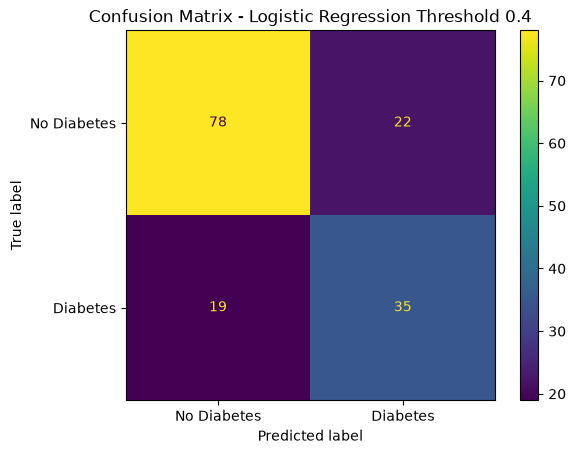

In [60]:
from sklearn.metrics import ConfusionMatrixDisplay

cm_threshold = confusion_matrix(y_test, y_pred_threshold)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_threshold,
    display_labels=["No Diabetes", "Diabetes"]
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression Threshold 0.4")
plt.show()

In [62]:
threshold_comparison =pd.DataFrame({
    "Threshold": [0.5,0.4],
    "Accuracy": [accuracy,accuracy_threshold],
    "Precision": [precision,precision_threshold],
    "Recall": [recall,recall_threshold],
    "F1-score": [f1,f1_threshold]
    
})
threshold_comparison

,Threshold,Accuracy,Precision,Recall,F1-score
0,0.5,0.740260,0.652174,0.555556,0.600000
1,0.4,0.733766,0.614035,0.648148,0.630631


## Cross Validation

In this step, I use Cross Validation to evaluate the model more reliably.

Instead of depending on only one train/test split, Cross Validation splits the training data into multiple parts.

The model trains and tests several times on different parts of the data.

This gives a more stable and trustworthy evaluation.

In [64]:
from sklearn.model_selection import cross_val_score

log_model_cv = LogisticRegression(max_iter=1000)

# Calculate cross-validation recall scores
recall_scores = cross_val_score(
    log_model_cv,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="recall"
)

print("Recall scores:", recall_scores)
print("Mean Recall:", recall_scores.mean())

Recall scores: [0.65116279 0.58139535 0.55813953 0.48837209 0.64285714]
Mean Recall: 0.5843853820598006


In [65]:
accuracy_scores=cross_val_score(
    log_model_cv,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy"
)
print("Accuracy scores:", accuracy_scores)
print("Mean Accuracy:", accuracy_scores.mean())

Accuracy scores: [0.7804878  0.7804878  0.76422764 0.7804878  0.80327869]
Mean Accuracy: 0.7817939490870318


## Hyperparameter Tuning

In this step, I tune the Random Forest model using GridSearchCV.

Hyperparameter tuning means trying different model settings to find the best combination.

The goal is to improve the model performance and choose better parameters instead of using default values.

## Random Forest Hyperparameters

The Random Forest parameters tested here are:

- `n_estimators`: number of trees in the forest
- `max_depth`: maximum depth of each tree
- `min_samples_split`: minimum number of samples needed to split a node

Changing these values can affect model complexity and performance.

In [67]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
rf_model=RandomForestClassifier(random_state=42)
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10]
}
grid_search= GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring="recall",
    n_jobs=1
)
grid_search.fit(X_train_scaled,y_train)
grid_search.best_params_

{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}

In [68]:
grid_search.best_score_

np.float64(0.6169435215946844)

In [70]:
best_rf_model=grid_search.best_estimator_
y_pred_best_rf = best_rf_model.predict(X_test_scaled)

In [71]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

accuracy_best_rf = accuracy_score(y_test, y_pred_best_rf)
precision_best_rf = precision_score(y_test, y_pred_best_rf)
recall_best_rf = recall_score(y_test, y_pred_best_rf)
f1_best_rf = f1_score(y_test, y_pred_best_rf)

print("Accuracy:", accuracy_best_rf)
print("Precision:", precision_best_rf)
print("Recall:", recall_best_rf)
print("F1-score:", f1_best_rf)

Accuracy: 0.7272727272727273
Precision: 0.6304347826086957
Recall: 0.5370370370370371
F1-score: 0.58


In [72]:
print(classification_report(y_test, y_pred_best_rf))

              precision    recall  f1-score   support

           0       0.77      0.83      0.80       100
           1       0.63      0.54      0.58        54

    accuracy                           0.73       154
   macro avg       0.70      0.68      0.69       154
weighted avg       0.72      0.73      0.72       154



## Feature Importance

I used the tuned Random Forest model to check feature importance.

Feature importance shows which features contributed the most to the model predictions.

This helps us understand which medical variables were most useful for predicting diabetes.

In this project, features such as Glucose, BMI, and Age are expected to be important because they are medically related to diabetes.

In [82]:
feature_importance=best_rf_model.feature_importances_
importance_df=pd.DataFrame({
    "Feature":X.columns,
    "Importance":feature_importance
})
importance_df=importance_df.sort_values(by="Importance",ascending=False)
importance_df

,Feature,Importance
1,Glucose,0.276505
5,BMI,0.170323
7,Age,0.123023
6,DiabetesPedigreeFunction,0.111628
4,Insulin,0.098698
0,Pregnancies,0.083208
2,BloodPressure,0.068377
3,SkinThickness,0.068238


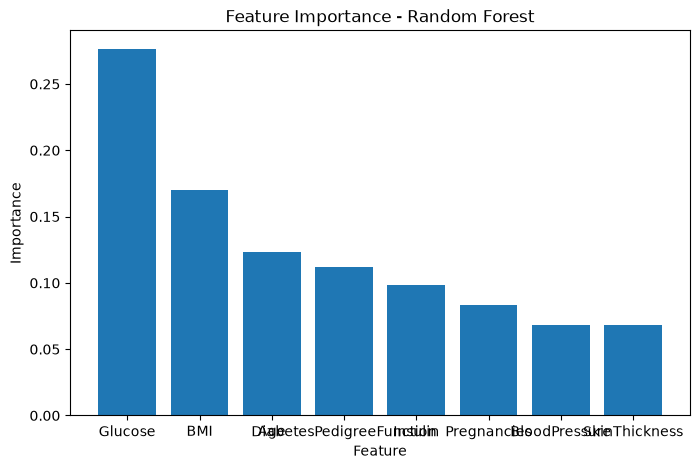

In [85]:
plt.figure(figsize=(8,5))
plt.bar(importance_df["Feature"],importance_df["Importance"])
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importance - Random Forest")
plt.show()

## Model Comparison

In this step, I combine the results of all models into one table.

This makes it easier to compare the models using:

- Accuracy
- Precision
- Recall
- F1-score

The best model should be chosen based on the goal of the project, not only the highest Accuracy.

In [94]:
# Create a DataFrame for the tuned Random Forest results
tuned_rf_result = pd.DataFrame({
    "Model": ["Tuned Random Forest"],
    "Accuracy": [accuracy_best_rf],
    "Precision": [precision_best_rf],
    "Recall": [recall_best_rf],
    "F1-score": [f1_best_rf]
})

tuned_rf_result

,Model,Accuracy,Precision,Recall,F1-score
0,Tuned Random Forest,0.727273,0.630435,0.537037,0.58


In [74]:
# Combine previous model results with tuned Random Forest result
comparison_results = pd.concat(
    [results_df, tuned_rf_result],
    ignore_index=True
)

comparison_results

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.707792,0.600000,0.500000,0.545455
1,KNN,0.753247,0.660000,0.611111,0.634615
2,Decision Tree,0.681818,0.553191,0.481481,0.514851
3,Random Forest,0.779221,0.717391,0.611111,0.660000
4,SVM,0.740260,0.652174,0.555556,0.600000
5,Tuned Random Forest,0.727273,0.630435,0.537037,0.580000


In [90]:
# Sort models by Recall
comparison_results=comparison_results.sort_values(by=["Recall","Precision"], ascending=False)
comparison_results

,Model,Accuracy,Precision,Recall,F1-score
3,Random Forest,0.779221,0.717391,0.611111,0.660000
1,KNN,0.753247,0.660000,0.611111,0.634615
4,SVM,0.740260,0.652174,0.555556,0.600000
5,Tuned Random Forest,0.727273,0.630435,0.537037,0.580000
0,Logistic Regression,0.707792,0.600000,0.500000,0.545455
2,Decision Tree,0.681818,0.553191,0.481481,0.514851


In [93]:
# Show the full row of the best model
best_model_result = comparison_results.iloc[0]

best_model_result

Model        Random Forest
Accuracy          0.779221
Precision         0.717391
Recall            0.611111
F1-score              0.66
Name: 3, dtype: object

## Final Model Selection

I selected the final model based mainly on Recall because this is a medical classification problem.

In diabetes prediction, missing a diabetic patient is risky.

Therefore, the best model is not necessarily the model with the highest accuracy.

I compared Accuracy, Precision, Recall, and F1-score, but I focused more on Recall for class 1.

The selected model is the model that detects more diabetic patients while keeping the overall performance acceptable.

## Step 1: Handle Class Imbalance

In this step, I improve the Logistic Regression model by using `class_weight="balanced"`.

The dataset has more No Diabetes cases than Diabetes cases.

This means the model may become better at predicting class 0 and weaker at detecting class 1.

Since this is a medical classification problem, detecting Diabetes cases is very important.

Using `class_weight="balanced"` tells the model to give more importance to the minority class.

The goal of this step is to improve Recall for class 1 and reduce False Negatives.

In [95]:
balanced_log_model=LogisticRegression(class_weight="balanced",max_iter=1000)
balanced_log_model.fit(X_train_scaled,y_train)
y_pred_balanced_log=balanced_log_model.predict(X_test_scaled)

accuracy_balanced_log = accuracy_score(y_test, y_pred_balanced_log)
precision_balanced_log = precision_score(y_test, y_pred_balanced_log)
recall_balanced_log = recall_score(y_test, y_pred_balanced_log)
f1_balanced_log = f1_score(y_test, y_pred_balanced_log)

print("Accuracy:", accuracy_balanced_log)
print("Precision:", precision_balanced_log)
print("Recall:", recall_balanced_log)
print("F1-score:", f1_balanced_log)

Accuracy: 0.7337662337662337
Precision: 0.6031746031746031
Recall: 0.7037037037037037
F1-score: 0.6495726495726496


In [96]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_balanced_log))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_balanced_log))


Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.75      0.79       100
           1       0.60      0.70      0.65        54

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.72       154
weighted avg       0.75      0.73      0.74       154


Confusion Matrix:
[[75 25]
 [16 38]]


<Figure size 800x600 with 0 Axes>

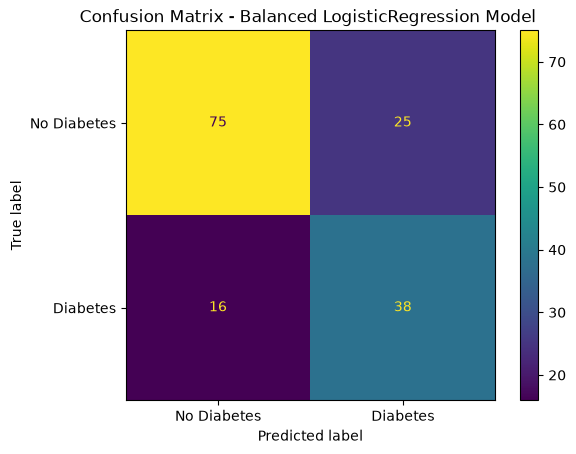

In [97]:
plt.figure(figsize=(8,6))
cm=confusion_matrix(y_test, y_pred_balanced_log)
disp=ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Diabetes", "Diabetes"]
)

disp.plot()
plt.title("Confusion Matrix - Balanced LogisticRegression Model ")
plt.show()

In [99]:
balanced_rf_model=RandomForestClassifier(class_weight="balanced",random_state=42)
balanced_rf_model.fit(X_train_scaled,y_train)
y_pred_balanced_rf=balanced_rf_model.predict(X_test_scaled)


accuracy_balanced_rf = accuracy_score(y_test, y_pred_balanced_rf)
precision_balanced_rf = precision_score(y_test, y_pred_balanced_rf)
recall_balanced_rf = recall_score(y_test, y_pred_balanced_rf)
f1_balanced_rf = f1_score(y_test, y_pred_balanced_rf)

print("Accuracy:", accuracy_balanced_rf)
print("Precision:", precision_balanced_rf)
print("Recall:", recall_balanced_rf)
print("F1-score:", f1_balanced_rf)

Accuracy: 0.7597402597402597
Precision: 0.6491228070175439
Recall: 0.6851851851851852
F1-score: 0.6666666666666666


<Figure size 800x600 with 0 Axes>

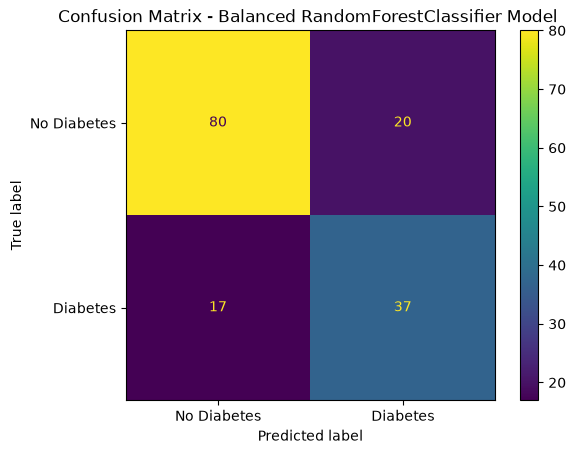

In [100]:
plt.figure(figsize=(8,6))
cm=confusion_matrix(y_test, y_pred_balanced_rf)
disp=ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Diabetes", "Diabetes"]
)

disp.plot()
plt.title("Confusion Matrix - Balanced RandomForestClassifier Model ")
plt.show()

In [102]:
y_proba_balanced=balanced_log_model.predict_proba(X_test_scaled)[:,1]
thresholds=[0.1,0.2,0.3,0.4,0.5,0.6,0.7]
threshold_results = []
for thres in thresholds:
    y_pred_threshold=(y_proba_balanced>=thres).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_threshold).ravel()
    threshold_results.append({
        "Threshold": thres,
        "Accuracy": accuracy_score(y_test, y_pred_threshold),
        "Precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "Recall": recall_score(y_test, y_pred_threshold),
        "F1-score": f1_score(y_test, y_pred_threshold),
        "False Negatives": fn,
        "False Positives": fp
    })
threshold_results_df=pd.DataFrame(threshold_results)
threshold_results_df=threshold_results_df.sort_values(by=["Recall","Accuracy","Precision","F1-score"],ascending=False)
threshold_results_df

,Threshold,Accuracy,Precision,Recall,F1-score,False Negatives,False Positives
1,0.2,0.668831,0.514563,0.981481,0.675159,1,50
0,0.1,0.500000,0.410853,0.981481,0.579235,1,76
2,0.3,0.701299,0.545455,0.888889,0.676056,6,40
3,0.4,0.720779,0.569620,0.833333,0.676692,9,34
4,0.5,0.733766,0.603175,0.703704,0.649573,16,25
5,0.6,0.714286,0.596154,0.574074,0.584906,23,21
6,0.7,0.714286,0.619048,0.481481,0.541667,28,16


In [104]:
best_threshold = 0.4

y_pred_best_threshold = (y_proba_balanced >= best_threshold).astype(int)

print("Best Threshold:", best_threshold)
print("Accuracy:", accuracy_score(y_test, y_pred_best_threshold))
print("Precision:", precision_score(y_test, y_pred_best_threshold))
print("Recall:", recall_score(y_test, y_pred_best_threshold))
print("F1-score:", f1_score(y_test, y_pred_best_threshold))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best_threshold))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best_threshold))

Best Threshold: 0.4
Accuracy: 0.7207792207792207
Precision: 0.569620253164557
Recall: 0.8333333333333334
F1-score: 0.6766917293233082

Confusion Matrix:
[[66 34]
 [ 9 45]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.66      0.75       100
           1       0.57      0.83      0.68        54

    accuracy                           0.72       154
   macro avg       0.72      0.75      0.72       154
weighted avg       0.77      0.72      0.73       154



## Step 3: Error Analysis

In this step, I analyze the model mistakes.

The goal is not only to know the score, but also to understand where the model fails.

I focus on:

- False Negatives: patients who actually have Diabetes, but the model predicted No Diabetes
- False Positives: patients who do not have Diabetes, but the model predicted Diabetes

False Negatives are more important in this project because missing a real Diabetes case can be risky.

By analyzing these wrong predictions, I can understand if there are patterns in the mistakes.

In [105]:
# Create a copy of the test data for error analysis
error_analysis_df = X_test.copy()

# Add true labels and predicted labels
error_analysis_df["Actual"] = y_test.values
error_analysis_df["Predicted"] = y_pred_best_threshold

# Add predicted probability for Diabetes
error_analysis_df["Diabetes_Probability"] = y_proba_balanced

error_analysis_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Actual,Predicted,Diabetes_Probability
44,7,159.0,64.0,29.0,125.0,27.4,0.294,40,0,1,0.733216
672,10,68.0,106.0,23.0,49.0,35.5,0.285,47,0,0,0.211852
700,2,122.0,76.0,27.0,200.0,35.9,0.483,26,0,1,0.439321
630,7,114.0,64.0,29.0,125.0,27.4,0.732,34,1,0,0.382703
81,2,74.0,72.0,29.0,125.0,32.3,0.102,22,0,0,0.054256


In [106]:
false_negatives = error_analysis_df[
    (error_analysis_df["Actual"] == 1) & 
    (error_analysis_df["Predicted"] == 0)
]

false_negatives

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Actual,Predicted,Diabetes_Probability
630,7,114.0,64.0,29.0,125.0,27.4,0.732,34,1,0,0.382703
678,3,121.0,52.0,29.0,125.0,36.0,0.127,25,1,0,0.398349
17,7,107.0,74.0,29.0,125.0,29.6,0.254,31,1,0,0.268677
124,0,113.0,76.0,29.0,125.0,33.3,0.278,23,1,0,0.218325
276,7,106.0,60.0,24.0,125.0,26.5,0.296,29,1,0,0.205937
419,3,129.0,64.0,29.0,115.0,26.4,0.219,28,1,0,0.273525
366,6,124.0,72.0,29.0,125.0,27.6,0.368,29,1,0,0.358739
6,3,78.0,50.0,32.0,88.0,31.0,0.248,26,1,0,0.077208
38,2,90.0,68.0,42.0,125.0,38.2,0.503,27,1,0,0.238838


In [107]:
false_negatives.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Actual,Predicted,Diabetes_Probability
count,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.0,9.0,9.000000
mean,4.222222,109.111111,64.444444,30.222222,119.777778,30.666667,0.336111,28.000000,1.0,0.0,0.269145
std,2.587362,16.374099,9.207485,4.867694,12.367071,4.315959,0.181153,3.278719,0.0,0.0,0.101225
min,0.000000,78.000000,50.000000,24.000000,88.000000,26.400000,0.127000,23.000000,1.0,0.0,0.077208
25%,3.000000,106.000000,60.000000,29.000000,125.000000,27.400000,0.248000,26.000000,1.0,0.0,0.218325
50%,3.000000,113.000000,64.000000,29.000000,125.000000,29.600000,0.278000,28.000000,1.0,0.0,0.268677
75%,7.000000,121.000000,72.000000,29.000000,125.000000,33.300000,0.368000,29.000000,1.0,0.0,0.358739
max,7.000000,129.000000,76.000000,42.000000,125.000000,38.200000,0.732000,34.000000,1.0,0.0,0.398349


In [110]:
false_positives = error_analysis_df[
    (error_analysis_df["Actual"] == 0) & 
    (error_analysis_df["Predicted"] == 1)
]

false_positives.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Actual,Predicted,Diabetes_Probability
44,7,159.0,64.0,29.0,125.0,27.4,0.294,40,0,1,0.733216
700,2,122.0,76.0,27.0,200.0,35.9,0.483,26,0,1,0.439321
335,0,165.0,76.0,43.0,255.0,47.9,0.259,26,0,1,0.906847
660,10,162.0,84.0,29.0,125.0,27.7,0.182,54,0,1,0.831727
260,3,191.0,68.0,15.0,130.0,30.9,0.299,34,0,1,0.887779


In [109]:
false_positives.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Actual,Predicted,Diabetes_Probability
count,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.0,34.0,34.000000
mean,5.147059,137.411765,78.264706,32.500000,187.352941,36.085294,0.440088,36.294118,0.0,1.0,0.669875
std,3.962952,28.040142,10.019099,9.567147,132.746485,7.248788,0.273364,14.044366,0.0,0.0,0.175087
min,0.000000,91.000000,50.000000,11.000000,64.000000,23.100000,0.126000,21.000000,0.0,1.0,0.401165
25%,2.000000,118.000000,72.750000,29.000000,125.000000,30.975000,0.246000,26.000000,0.0,1.0,0.503408
50%,4.500000,137.000000,79.000000,32.000000,125.000000,35.800000,0.370000,29.000000,0.0,1.0,0.661408
75%,8.000000,154.000000,84.750000,39.750000,190.500000,40.600000,0.583000,45.750000,0.0,1.0,0.804312
max,13.000000,194.000000,95.000000,54.000000,680.000000,52.300000,1.476000,68.000000,0.0,1.0,0.952606


## Step 7: Feature Engineering

In this step, I create new features from the existing features.

The goal is to help the model capture relationships between important medical variables.

From the error analysis, I noticed that some mistakes are related to combinations of features such as Glucose, BMI, and Age.

Feature engineering can help the model understand these interactions better.

Examples:

- High Glucose
- High BMI
- Glucose multiplied by BMI
- BMI multiplied by Age

These new features may improve the model performance.

In [111]:
X_train_fe=X_train.copy()
X_test_fe=X_test.copy()
X_train_fe["BMI_Age"]=X_train_fe["BMI"]*X_train_fe["Age"]
X_test_fe["BMI_Age"]=X_test_fe["BMI"]*X_test_fe["Age"]

X_train_fe["Glucose_BMI"] = X_train_fe["Glucose"] * X_train_fe["BMI"]
X_test_fe["Glucose_BMI"] = X_test_fe["Glucose"] * X_test_fe["BMI"]

X_train_fe["High_Glucose"] = (X_train_fe["Glucose"] > 140).astype(int)
X_test_fe["High_Glucose"] = (X_test_fe["Glucose"] > 140).astype(int)

X_train_fe["High_BMI"] = (X_train_fe["BMI"] >= 30).astype(int)
X_test_fe["High_BMI"] = (X_test_fe["BMI"] >= 30).astype(int)

X_train_fe.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,BMI_Age,Glucose_BMI,High_Glucose,High_BMI
353,1,90.0,62.0,12.0,43.0,27.2,0.580,24,652.8,2448.0,0,0
711,5,126.0,78.0,27.0,22.0,29.6,0.439,40,1184.0,3729.6,0,0
373,2,105.0,58.0,40.0,94.0,34.9,0.225,25,872.5,3664.5,0,1
46,1,146.0,56.0,29.0,125.0,29.7,0.564,29,861.3,4336.2,1,0
682,0,95.0,64.0,39.0,105.0,44.6,0.366,22,981.2,4237.0,0,1


## Scaling After Feature Engineering

After creating new features, I need to scale the updated feature set again.

Scaling is important for Logistic Regression because it helps the model train better when features have different ranges.

In [112]:
scaler_fe = StandardScaler()

X_train_fe_scaled = scaler_fe.fit_transform(X_train_fe)
X_test_fe_scaled = scaler_fe.transform(X_test_fe)

## Step 8: Train Logistic Regression After Feature Engineering

In this step, I train Logistic Regression again using the new engineered features.

The goal is to check if the new features improved the model performance.

I will compare this model with the previous Logistic Regression model.

If Recall, F1-score, or False Negatives improve, this means the new features helped the model.

In [116]:
log_model_fe = LogisticRegression(class_weight="balanced", max_iter=1000)
log_model_fe.fit(X_train_fe_scaled, y_train)
y_proba_fe = log_model_fe.predict_proba(X_test_fe_scaled)[:, 1]
best_threshold = 0.4
y_pred_fe = (y_proba_fe >= best_threshold).astype(int)

# Evaluate the model
accuracy_fe = accuracy_score(y_test, y_pred_fe)
precision_fe = precision_score(y_test, y_pred_fe)
recall_fe = recall_score(y_test, y_pred_fe)
f1_fe = f1_score(y_test, y_pred_fe)

print("Accuracy:", accuracy_fe)
print("Precision:", precision_fe)
print("Recall:", recall_fe)
print("F1-score:", f1_fe)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_fe))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_fe))


Accuracy: 0.7272727272727273
Precision: 0.575
Recall: 0.8518518518518519
F1-score: 0.6865671641791045

Confusion Matrix:
[[66 34]
 [ 8 46]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.66      0.76       100
           1       0.57      0.85      0.69        54

    accuracy                           0.73       154
   macro avg       0.73      0.76      0.72       154
weighted avg       0.78      0.73      0.73       154



In [117]:
# Confusion matrix values for feature engineering model
tn_fe, fp_fe, fn_fe, tp_fe = confusion_matrix(y_test, y_pred_fe).ravel()

# Confusion matrix values for previous best threshold model
tn_old, fp_old, fn_old, tp_old = confusion_matrix(y_test, y_pred_best_threshold).ravel()

comparison_fe = pd.DataFrame({
    "Model": ["Before Feature Engineering", "After Feature Engineering"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_best_threshold),
        accuracy_fe
    ],
    "Precision": [
        precision_score(y_test, y_pred_best_threshold),
        precision_fe
    ],
    "Recall": [
        recall_score(y_test, y_pred_best_threshold),
        recall_fe
    ],
    "F1-score": [
        f1_score(y_test, y_pred_best_threshold),
        f1_fe
    ],
    "False Negatives": [
        fn_old,
        fn_fe
    ],
    "False Positives": [
        fp_old,
        fp_fe
    ]
})

comparison_fe.sort_values(by="Recall",ascending=False)

,Model,Accuracy,Precision,Recall,F1-score,False Negatives,False Positives
1,After Feature Engineering,0.727273,0.57500,0.851852,0.686567,8,34
0,Before Feature Engineering,0.720779,0.56962,0.833333,0.676692,9,34


## Step 1: Prepare Data for Improved Imputation

In this step, I prepare the dataset again for better missing value handling.

Some columns in this dataset cannot logically have a value of zero, such as Glucose, BloodPressure, SkinThickness, Insulin, and BMI.

A zero value in these columns probably means missing data.

Instead of directly replacing zeros with the median, I first convert these invalid zero values into NaN.

This allows me to test different imputation methods and compare which one improves the model performance.

In [122]:
df_impute=pd.read_csv("diabetes.csv")
invalid_zero_cols=["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df_impute[invalid_zero_cols] = df_impute[invalid_zero_cols].replace(0, np.nan)
df_impute.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [123]:
X_impute = df_impute.drop("Outcome", axis=1)
y_impute = df_impute["Outcome"]

In [138]:
from sklearn.model_selection import train_test_split

X_train_imp, X_test_imp, y_train_imp, y_test_imp = train_test_split(
    X_impute,
    y_impute,
    test_size=0.2,
    random_state=42,
    stratify=y_impute
)

In [139]:

X_train_imp["BMI_Age"]=X_train_imp["BMI"]*X_train_imp["Age"]
X_test_imp["BMI_Age"]=X_test_imp["BMI"]*X_test_imp["Age"]

X_train_imp["Glucose_BMI"] = X_train_imp["Glucose"] * X_train_imp["BMI"]
X_test_imp["Glucose_BMI"] = X_test_imp["Glucose"] * X_test_imp["BMI"]

X_train_imp["High_Glucose"] = (X_train_imp["Glucose"] > 140).astype(int)
X_test_imp["High_Glucose"] = (X_test_imp["Glucose"] > 140).astype(int)

X_train_imp["High_BMI"] = (X_train_imp["BMI"] >= 30).astype(int)
X_test_imp["High_BMI"] = (X_test_imp["BMI"] >= 30).astype(int)

X_train_imp.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,BMI_Age,Glucose_BMI,High_Glucose,High_BMI
353,1,90.0,62.0,12.0,43.0,27.2,0.580,24,652.8,2448.0,0,0
711,5,126.0,78.0,27.0,22.0,29.6,0.439,40,1184.0,3729.6,0,0
373,2,105.0,58.0,40.0,94.0,34.9,0.225,25,872.5,3664.5,0,1
46,1,146.0,56.0,NaN,NaN,29.7,0.564,29,861.3,4336.2,1,0
682,0,95.0,64.0,39.0,105.0,44.6,0.366,22,981.2,4237.0,0,1


## KNN Imputation

In this step, I use KNNImputer.

KNNImputer fills missing values based on similar patients.

For example, instead of filling missing Insulin with one median value for everyone, it looks for patients with similar feature values and uses them to estimate the missing value.

This can be better than simple median imputation because it uses relationships between features.

However, it may not always improve the model, so I need to test it.

In [140]:
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

knn_pipeline= Pipeline([
    ("scalar",StandardScaler()),
    ("KNNImputer",KNNImputer(n_neighbors=5)),
    ("model",LogisticRegression(class_weight="balanced",max_iter=1000))
])
knn_pipeline.fit(X_train_imp, y_train_imp)

y_proba_knn=knn_pipeline.predict_proba(X_test_imp)[:, 1]
y_pred_knn=(y_proba_knn>=0.4).astype(int)


tn, fp, fn, tp = confusion_matrix(y_test_imp, y_pred_knn).ravel()

knn_result = {
    "Method": "KNN Imputation",
    "Accuracy": accuracy_score(y_test_imp, y_pred_knn),
    "Precision": precision_score(y_test_imp, y_pred_knn),
    "Recall": recall_score(y_test_imp, y_pred_knn),
    "F1-score": f1_score(y_test_imp, y_pred_knn),
    "False Negatives": fn,
    "False Positives": fp
}

knn_result

{'Method': 'KNN Imputation',
 'Accuracy': 0.7272727272727273,
 'Precision': 0.575,
 'Recall': 0.8518518518518519,
 'F1-score': 0.6865671641791045,
 'False Negatives': np.int64(8),
 'False Positives': np.int64(34)}

## Iterative Imputation

In this step, I use IterativeImputer.

IterativeImputer predicts missing values using the other features.

For example, it can estimate missing Insulin using Glucose, BMI, Age, BloodPressure, and other available columns.

This method is more advanced than median imputation because it treats missing value handling like a prediction problem.

However, it is more complex and may take more time.

In [141]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

iterative_pipeline = Pipeline([
    ("imputer", IterativeImputer(random_state=42, max_iter=10)),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000))
])

iterative_pipeline.fit(X_train_imp, y_train_imp)

y_proba_iterative = iterative_pipeline.predict_proba(X_test_imp)[:, 1]
y_pred_iterative = (y_proba_iterative >= 0.4).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test_imp, y_pred_iterative).ravel()

iterative_result = {
    "Method": "Iterative Imputation",
    "Accuracy": accuracy_score(y_test_imp, y_pred_iterative),
    "Precision": precision_score(y_test_imp, y_pred_iterative),
    "Recall": recall_score(y_test_imp, y_pred_iterative),
    "F1-score": f1_score(y_test_imp, y_pred_iterative),
    "False Negatives": fn,
    "False Positives": fp
}

iterative_result

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


{'Method': 'Iterative Imputation',
 'Accuracy': 0.7272727272727273,
 'Precision': 0.575,
 'Recall': 0.8518518518518519,
 'F1-score': 0.6865671641791045,
 'False Negatives': np.int64(8),
 'False Positives': np.int64(34)}

##  Compare Imputation Methods

In this step, I compare different imputation methods.

The goal is to check whether advanced imputation methods improved the model compared to simple median imputation.

I focus on:

- Recall
- F1-score
- False Negatives
- Precision

The best imputation method is not always the most complex one.

The best method is the one that improves model performance on unseen test data.

In [142]:
imputation_results = pd.DataFrame([
    knn_result,
    iterative_result
])

imputation_results.sort_values(by=["Recall", "F1-score"], ascending=False)

,Method,Accuracy,Precision,Recall,F1-score,False Negatives,False Positives
0,KNN Imputation,0.727273,0.575,0.851852,0.686567,8,34
1,Iterative Imputation,0.727273,0.575,0.851852,0.686567,8,34


##  Gradient Boosting Classifier

In this step, I train a Gradient Boosting Classifier.

Gradient Boosting is an ensemble model that builds trees sequentially.

Each new tree tries to correct the mistakes made by the previous trees.

This model can capture non-linear relationships between features, which may improve performance on tabular data.

The goal is to check if Gradient Boosting performs better than Logistic Regression with KNN Imputation.

In [143]:
from sklearn.ensemble import GradientBoostingClassifier
gb_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("imputer", KNNImputer(n_neighbors=5)),
    ("model", GradientBoostingClassifier(random_state=42))
])
gb_pipeline.fit(X_train_imp,y_train_imp)
y_proba_gb = gb_pipeline.predict_proba(X_test_imp)[:, 1]

best_threshold = 0.4
y_pred_gb = (y_proba_gb >= best_threshold).astype(int)

accuracy_gb = accuracy_score(y_test_imp, y_pred_gb)
precision_gb = precision_score(y_test_imp, y_pred_gb)
recall_gb = recall_score(y_test_imp, y_pred_gb)
f1_gb = f1_score(y_test_imp, y_pred_gb)

tn_gb, fp_gb, fn_gb, tp_gb = confusion_matrix(y_test_imp, y_pred_gb).ravel()

print("Accuracy:", accuracy_gb)
print("Precision:", precision_gb)
print("Recall:", recall_gb)
print("F1-score:", f1_gb)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_imp, y_pred_gb))

print("\nClassification Report:")
print(classification_report(y_test_imp, y_pred_gb))

Accuracy: 0.7467532467532467
Precision: 0.6229508196721312
Recall: 0.7037037037037037
F1-score: 0.6608695652173913

Confusion Matrix:
[[77 23]
 [16 38]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.77      0.80       100
           1       0.62      0.70      0.66        54

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



##  Compare Logistic Regression with Gradient Boosting

In this step, I compare the best Logistic Regression model with Gradient Boosting.

The comparison helps me decide whether the stronger model actually improved performance.

I focus on:

- Recall
- F1-score
- False Negatives
- Precision
- Accuracy

The best model is not chosen by its name, but by its results on unseen test data.

In [144]:
gb_result = {
    "Model": "Gradient Boosting + KNN Imputation",
    "Accuracy": accuracy_gb,
    "Precision": precision_gb,
    "Recall": recall_gb,
    "F1-score": f1_gb,
    "False Negatives": fn_gb,
    "False Positives": fp_gb
}

knn_log_result = {
    "Model": "Logistic Regression + KNN Imputation",
    "Accuracy": 0.733766,
    "Precision": 0.582278,
    "Recall": 0.851852,
    "F1-score": 0.691729,
    "False Negatives": 8,
    "False Positives": 33
}

model_comparison = pd.DataFrame([
    knn_log_result,
    gb_result
])

model_comparison.sort_values(by=["Recall", "F1-score"], ascending=False)

,Model,Accuracy,Precision,Recall,F1-score,False Negatives,False Positives
0,Logistic Regression + KNN Imputation,0.733766,0.582278,0.851852,0.691729,8,33
1,Gradient Boosting + KNN Imputation,0.746753,0.622951,0.703704,0.660870,16,23


## Gradient Boosting Results

After comparing Logistic Regression with Gradient Boosting, Logistic Regression with KNN Imputation performed better for this project goal.

Gradient Boosting achieved slightly higher Accuracy and Precision, and it reduced False Positives.

However, it had lower Recall and more False Negatives.

Since this is a Diabetes Prediction project, missing real Diabetes cases is more risky than predicting extra false positives.

Therefore, Logistic Regression with KNN Imputation is still the better model because it has higher Recall, higher F1-score, and fewer False Negatives.

## Step 10: Threshold Tuning for Gradient Boosting

In this step, I test different decision thresholds for the Gradient Boosting model.

The previous Gradient Boosting model had higher Accuracy and Precision, but lower Recall and more False Negatives.

This means the model was more conservative when predicting Diabetes.

By lowering the threshold, the model may detect more Diabetes cases and reduce False Negatives.

The goal is to find a better threshold that improves Recall while keeping Precision and F1-score acceptable.

In [145]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

gb_threshold_results = []

for threshold in thresholds:
    y_pred_gb_threshold = (y_proba_gb >= threshold).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_test_imp, y_pred_gb_threshold).ravel()
    
    gb_threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test_imp, y_pred_gb_threshold),
        "Precision": precision_score(y_test_imp, y_pred_gb_threshold, zero_division=0),
        "Recall": recall_score(y_test_imp, y_pred_gb_threshold),
        "F1-score": f1_score(y_test_imp, y_pred_gb_threshold),
        "False Negatives": fn,
        "False Positives": fp
    })

gb_threshold_results_df = pd.DataFrame(gb_threshold_results)

gb_threshold_results_df.sort_values(by=["Recall", "F1-score"], ascending=False)

,Threshold,Accuracy,Precision,Recall,F1-score,False Negatives,False Positives
0,0.1,0.649351,0.500000,0.944444,0.653846,3,51
1,0.2,0.733766,0.578313,0.888889,0.700730,6,35
2,0.3,0.740260,0.597222,0.796296,0.682540,11,29
3,0.4,0.746753,0.622951,0.703704,0.660870,16,23
4,0.5,0.720779,0.607843,0.574074,0.590476,23,20
5,0.6,0.694805,0.581395,0.462963,0.515464,29,18
6,0.7,0.733766,0.709677,0.407407,0.517647,32,9


## Final Gradient Boosting Threshold Selection

After testing multiple thresholds for Gradient Boosting, I selected threshold = 0.2.

At this threshold, Gradient Boosting achieved the best balance for this project goal.

Compared with Logistic Regression, Gradient Boosting with threshold = 0.2 had higher Recall, higher F1-score, and fewer False Negatives.

This is important because the main goal in this Diabetes Prediction project is to detect as many real Diabetes cases as possible.

Although False Positives increased slightly, this trade-off is acceptable because reducing False Negatives is more important in a medical screening problem.

Therefore, Gradient Boosting with KNN Imputation and threshold = 0.2 is selected as the best model so far.

In [146]:
best_gb_threshold = 0.2

y_pred_best_gb = (y_proba_gb >= best_gb_threshold).astype(int)

print("Best Gradient Boosting Threshold:", best_gb_threshold)
print("Accuracy:", accuracy_score(y_test_imp, y_pred_best_gb))
print("Precision:", precision_score(y_test_imp, y_pred_best_gb))
print("Recall:", recall_score(y_test_imp, y_pred_best_gb))
print("F1-score:", f1_score(y_test_imp, y_pred_best_gb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_imp, y_pred_best_gb))

print("\nClassification Report:")
print(classification_report(y_test_imp, y_pred_best_gb))

Best Gradient Boosting Threshold: 0.2
Accuracy: 0.7337662337662337
Precision: 0.5783132530120482
Recall: 0.8888888888888888
F1-score: 0.7007299270072993

Confusion Matrix:
[[65 35]
 [ 6 48]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.65      0.76       100
           1       0.58      0.89      0.70        54

    accuracy                           0.73       154
   macro avg       0.75      0.77      0.73       154
weighted avg       0.80      0.73      0.74       154



In [147]:
final_comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression + KNN Imputation",
        "Threshold": 0.4,
        "Accuracy": 0.733766,
        "Precision": 0.582278,
        "Recall": 0.851852,
        "F1-score": 0.691729,
        "False Negatives": 8,
        "False Positives": 33
    },
    {
        "Model": "Gradient Boosting + KNN Imputation",
        "Threshold": 0.2,
        "Accuracy": accuracy_score(y_test_imp, y_pred_best_gb),
        "Precision": precision_score(y_test_imp, y_pred_best_gb),
        "Recall": recall_score(y_test_imp, y_pred_best_gb),
        "F1-score": f1_score(y_test_imp, y_pred_best_gb),
        "False Negatives": confusion_matrix(y_test_imp, y_pred_best_gb).ravel()[2],
        "False Positives": confusion_matrix(y_test_imp, y_pred_best_gb).ravel()[1]
    }
])

final_comparison.sort_values(
    by=["Recall", "F1-score"],
    ascending=False
)

,Model,Threshold,Accuracy,Precision,Recall,F1-score,False Negatives,False Positives
1,Gradient Boosting + KNN Imputation,0.2,0.733766,0.578313,0.888889,0.700730,6,35
0,Logistic Regression + KNN Imputation,0.4,0.733766,0.582278,0.851852,0.691729,8,33


## Final Conclusion

In this project, I built and improved a Diabetes Prediction classification model.

At first, I trained baseline models and evaluated them using Accuracy, Precision, Recall, F1-score, ROC-AUC, and Confusion Matrix.

Because this is a medical classification problem, Accuracy alone was not enough.

The main focus was reducing False Negatives, because missing a patient who actually has Diabetes can be risky.

To improve the model, I applied several techniques:

- Class weight balancing
- Threshold tuning
- Error analysis
- Feature engineering
- Improved missing value handling using KNN Imputation
- Gradient Boosting Classifier

After comparing the results, the best final model was:

Gradient Boosting + KNN Imputation + threshold = 0.2

This model achieved the best balance for the project goal because it had higher Recall, higher F1-score, and fewer False Negatives.

This project helped me understand that improving a machine learning model is not only about trying stronger algorithms.

A good ML Engineer improves the full workflow, including preprocessing, feature engineering, evaluation, threshold selection, and model comparison.

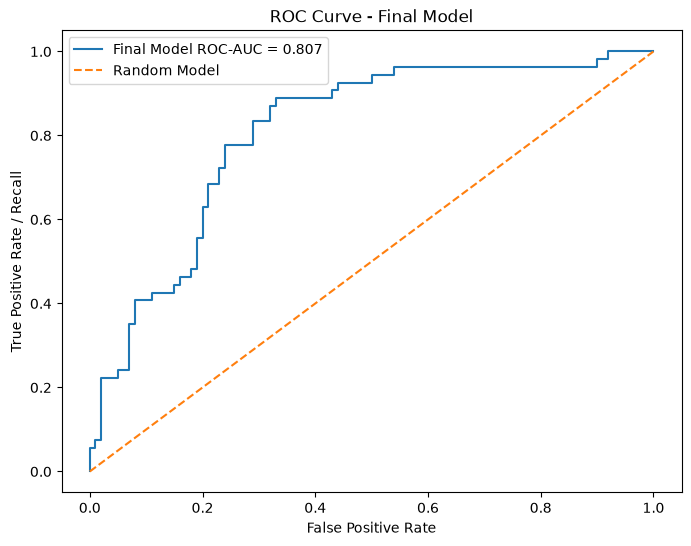

Final Model ROC-AUC: 0.807037037037037


In [149]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate ROC curve values
fpr, tpr, thresholds = roc_curve(y_test_imp, y_proba_gb)

# Calculate ROC-AUC score
roc_auc_final = roc_auc_score(y_test_imp, y_proba_gb)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Final Model ROC-AUC = {roc_auc_final:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Model")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Recall")
plt.title("ROC Curve - Final Model")
plt.legend()
plt.show()

print("Final Model ROC-AUC:", roc_auc_final)

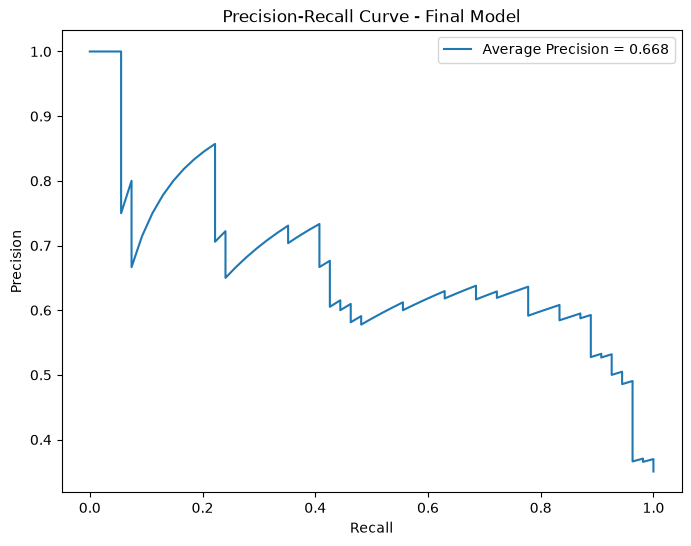

Average Precision Score: 0.6682542141836778


In [150]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Calculate Precision-Recall curve values
precision_values, recall_values, pr_thresholds = precision_recall_curve(y_test_imp, y_proba_gb)

# Calculate Average Precision score
average_precision = average_precision_score(y_test_imp, y_proba_gb)

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall_values, precision_values, label=f"Average Precision = {average_precision:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Final Model")
plt.legend()
plt.show()

print("Average Precision Score:", average_precision)

In [152]:
import joblib

# Save final pipeline
joblib.dump(gb_pipeline, "final_diabetes_model.pkl")

# Save selected threshold
joblib.dump(best_gb_threshold, "final_threshold.pkl")

print("Final model and threshold saved successfully.")

Final model and threshold saved successfully.
